Code to set path root

In [1]:
import sys
import os
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)


sys.path.append(os.path.abspath(".."))

# Training model on `fight-weaponized-other-dataset` with 64x64 Image Sizes
* using `datasets`, `transforms` module from `torchvison`
* using `dataloader` module from `torch.utils.data`

## Importing necessary Modules

In [2]:
# Import torch libraries
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn

# Import modules
from modules.architectures.Architecture import Architecture, ResidualBlock
from modules.helper.Trainer import Trainer
from modules.helper.Plotter import plot_training_metrics, plot_testing_history
from modules.helper.Tester import  Tester

Check if CUDA is used

In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device name:", torch.cuda.get_device_name(0))
    print("Current device index:", torch.cuda.current_device())
    print("Device count:", torch.cuda.device_count())
else:
    print("Running on CPU")

CUDA available: True
CUDA device name: NVIDIA GeForce RTX 4070 Laptop GPU
Current device index: 0
Device count: 1


### Use datasets, dataloader and transforms for loading training Dataset

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])
train_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/train",
    transform = train_transform
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    shuffle=True
)

print("Total Batches => ", len(train_dataloader))

Total Batches =>  67


### Use datasets, dataloader and transforms for loading validation Dataset

In [5]:
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

val_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/val",
    transform = val_transform
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print("Total Batches => ", len(val_dataloader))

Total Batches =>  15


### Using Model Architecture:
* 10 Convolutional Layers
    - Conv2D
    - BatchNorm2D
    - ReLu
    - MaxPool2D (Optional)
* 1 Linear Layer
* SDG Optimizer

In [6]:
model = Architecture().to("cuda")

In [ ]:
model = model.add( 
    # 1st block
    nn.Conv2d(3, 8, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(8),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    # 2nd block
    nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    # 3rd block
    nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    # 4th block (NO POOL)
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),

    # 5th block (NO POOL)
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),

    # Flatten
    nn.Flatten(),

    # 64x64 → 32 → 16 → 8 (final map = 128 × 8 × 8)
    nn.Linear(128 * 8 * 8, 128),
    nn.ReLU(),
    nn.Linear(128, 3)
)

### Use Trainer to train and check validations

In [8]:
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [9]:
trainer = Trainer(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer=optimizer, 
    num_classes=3,
    criterion=criterion,
    device="cuda",
    save_dir="../models/experiment2/",
    save_checkpoints=1,
    print_every=10
    )

In [10]:
history = trainer.fit(100)

Epoch [10/100] | Train Loss: 0.4379 | Val Loss: 0.6364 | Train Acc: 0.8696 | Val Acc: 0.7544 | Train F1: 0.8702 | Val F1: 0.7562
Epoch [20/100] | Train Loss: 0.2342 | Val Loss: 0.5688 | Train Acc: 0.9504 | Val Acc: 0.7920 | Train F1: 0.9507 | Val F1: 0.7928
Epoch [30/100] | Train Loss: 0.1261 | Val Loss: 0.5615 | Train Acc: 0.9839 | Val Acc: 0.8075 | Train F1: 0.9839 | Val F1: 0.8082
Epoch [40/100] | Train Loss: 0.0721 | Val Loss: 0.5779 | Train Acc: 0.9972 | Val Acc: 0.8142 | Train F1: 0.9972 | Val F1: 0.8145
Epoch [50/100] | Train Loss: 0.0454 | Val Loss: 0.6083 | Train Acc: 1.0000 | Val Acc: 0.8186 | Train F1: 1.0000 | Val F1: 0.8188
Epoch [60/100] | Train Loss: 0.0305 | Val Loss: 0.5973 | Train Acc: 0.9991 | Val Acc: 0.8186 | Train F1: 0.9991 | Val F1: 0.8200
Epoch [70/100] | Train Loss: 0.0228 | Val Loss: 0.6216 | Train Acc: 0.9991 | Val Acc: 0.8142 | Train F1: 0.9991 | Val F1: 0.8151
Epoch [80/100] | Train Loss: 0.0210 | Val Loss: 0.6557 | Train Acc: 0.9986 | Val Acc: 0.8119 | Tr

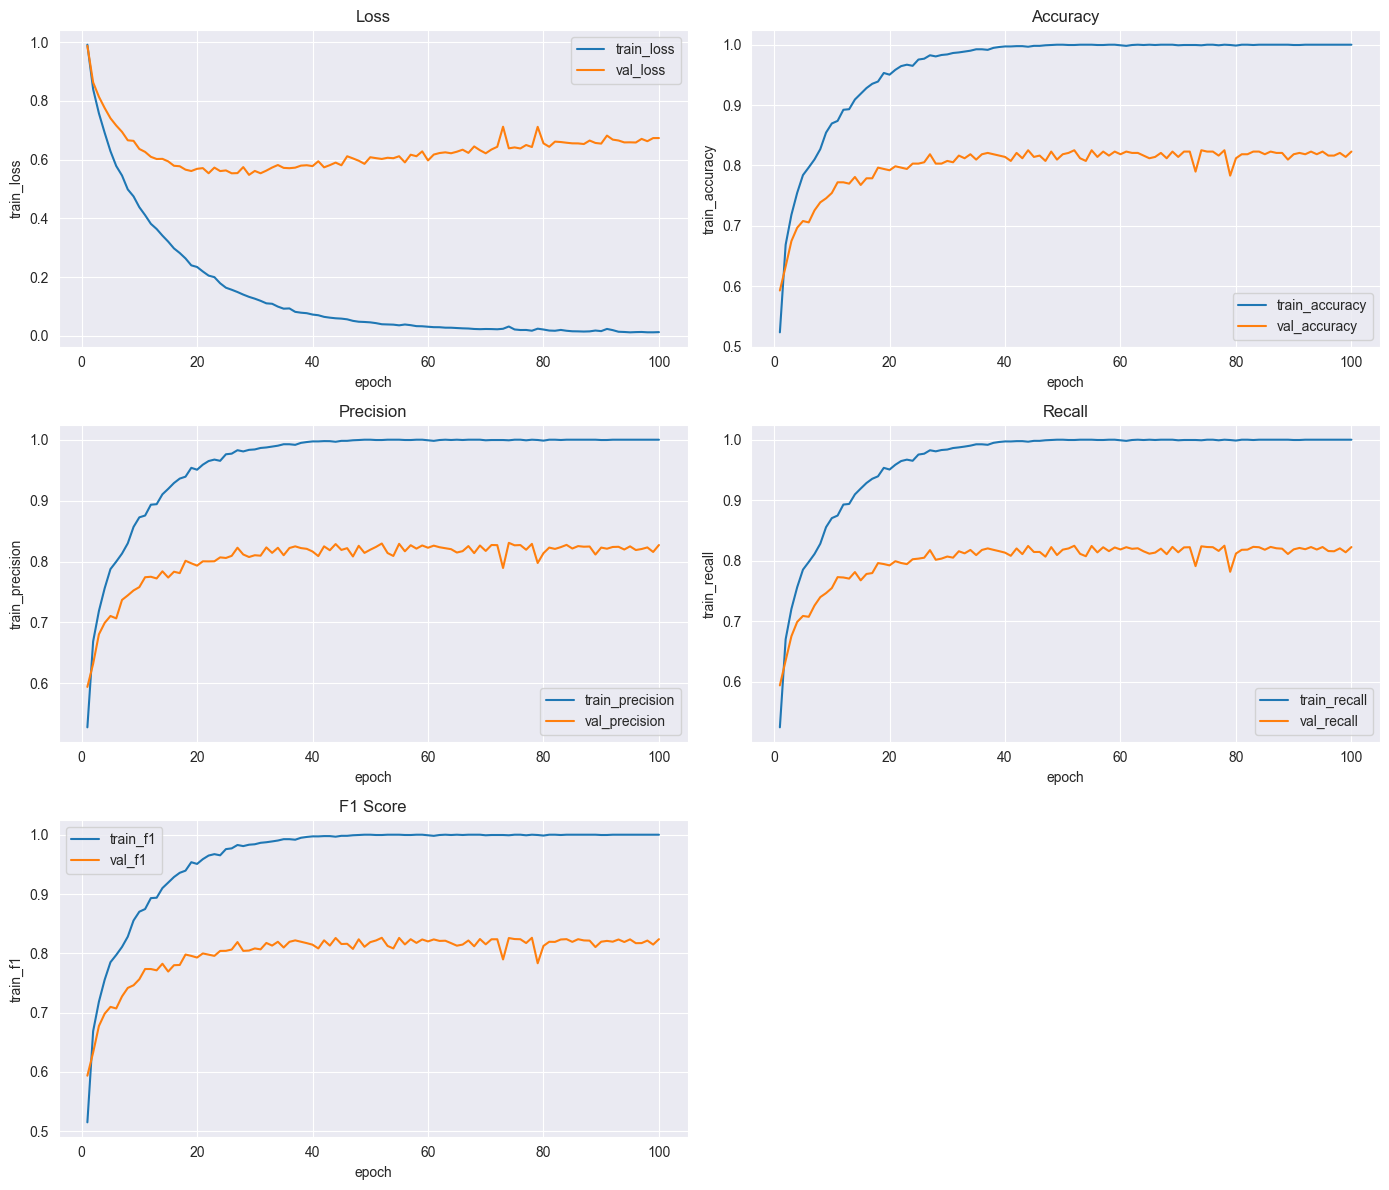

In [11]:
df = plot_training_metrics(history)

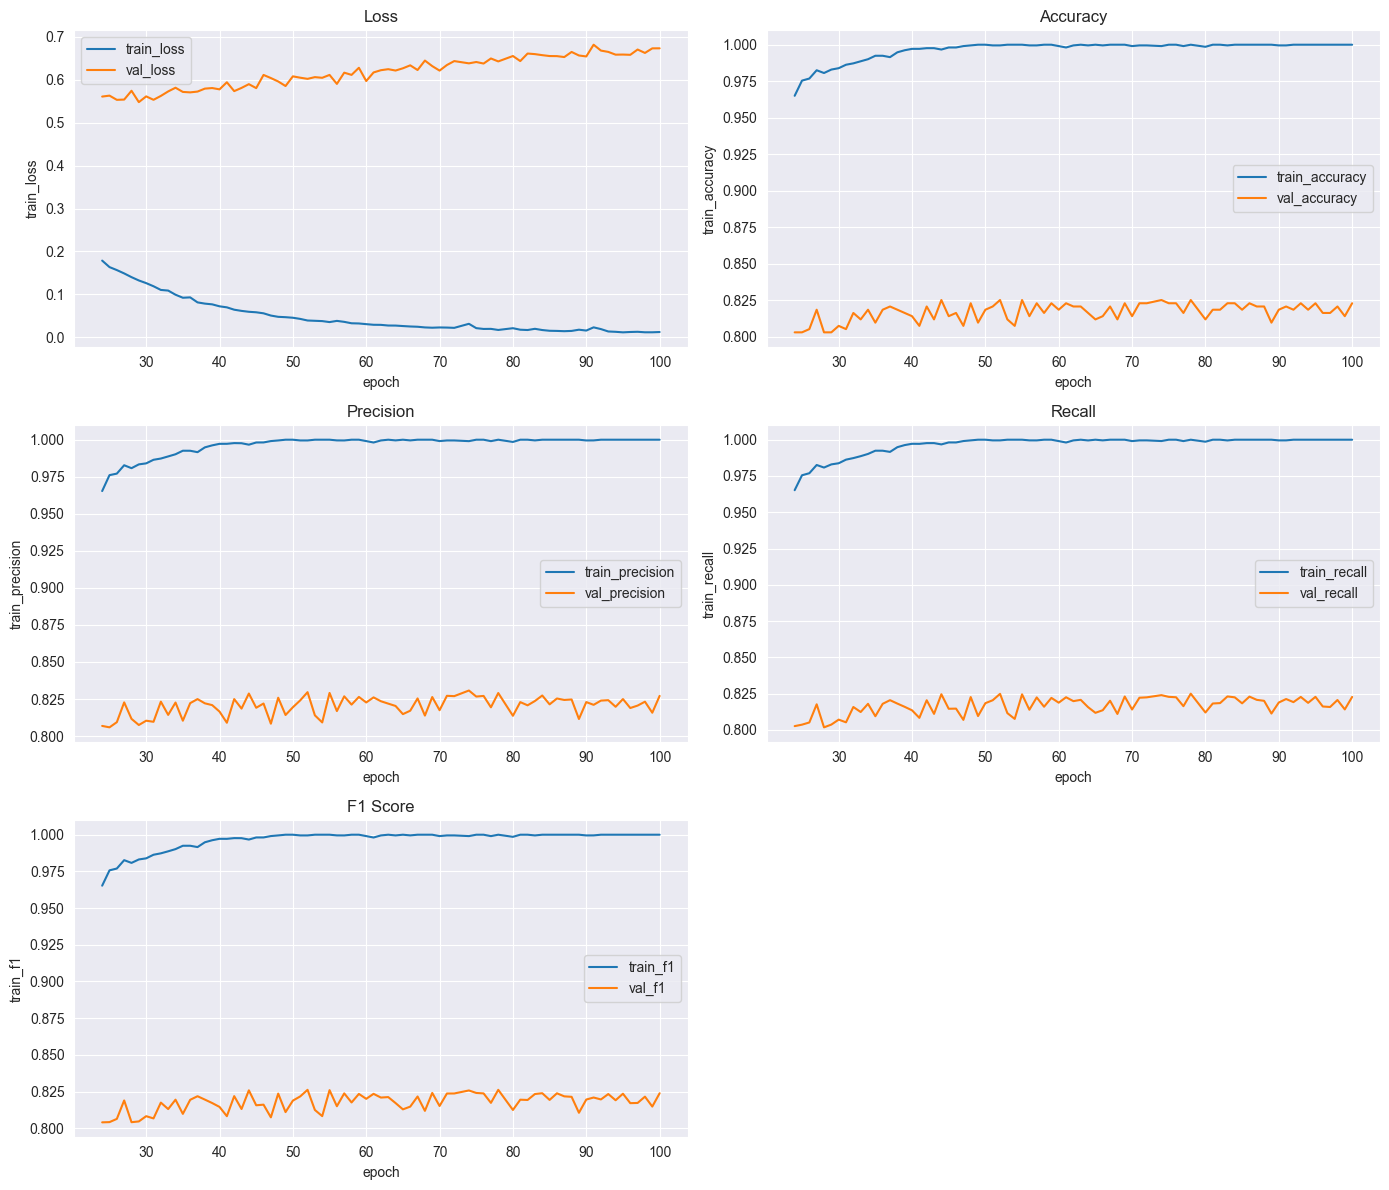

In [17]:
filtered_df = df[
    (df["val_accuracy"] >= 0.8) &
    (df["val_f1"] >= 0.8)
].to_dict()

high_accuracy_df = plot_training_metrics(filtered_df)

In [18]:
df

,epoch,train_loss,val_loss,train_accuracy,train_precision,train_recall,train_f1,val_accuracy,val_precision,val_recall,val_f1,confusion_matrix
0,1,0.991768,0.988097,0.523629,0.527833,0.525095,0.514937,0.592920,0.594208,0.594351,0.593606,"[[tensor(91), tensor(28), tensor(23)], [tensor(40), tensor(88), tensor(29)], [tensor(23), tensor(41), tensor(89)]]"
1,2,0.840024,0.863238,0.668715,0.668997,0.670493,0.668741,0.632743,0.632237,0.635366,0.632738,"[[tensor(101), tensor(21), tensor(20)], [tensor(32), tensor(86), tensor(39)], [tensor(21), tensor(33), tensor(99)]]"
2,3,0.757884,0.814370,0.718336,0.718818,0.720598,0.718425,0.674779,0.680573,0.675534,0.677422,"[[tensor(99), tensor(24), tensor(19)], [tensor(20), tensor(102), tensor(35)], [tensor(11), tensor(38), tensor(104)]]"
3,4,0.691353,0.775859,0.754726,0.756291,0.756495,0.755562,0.696903,0.699324,0.699180,0.698214,"[[tensor(111), tensor(21), tensor(10)], [tensor(24), tensor(105), tensor(28)], [tensor(16), tensor(38), tensor(99)]]"
4,5,0.628893,0.741120,0.784026,0.787611,0.785483,0.784986,0.707965,0.710641,0.709007,0.709647,"[[tensor(106), tensor(21), tensor(15)], [tensor(19), tensor(109), tensor(29)], [tensor(14), tensor(34), tensor(105)]]"
5,6,0.578269,0.716286,0.796786,0.799921,0.798121,0.797251,0.705752,0.706711,0.707612,0.707022,"[[tensor(109), tensor(20), tensor(13)], [tensor(24), tensor(104), tensor(29)], [tensor(14), tensor(33), tensor(106)]]"
6,7,0.545990,0.694699,0.810019,0.813086,0.811322,0.810771,0.725664,0.736988,0.726221,0.727302,"[[tensor(109), tensor(26), tensor(7)], [tensor(13), tensor(122), tensor(22)], [tensor(15), tensor(41), tensor(97)]]"
7,8,0.498527,0.665909,0.827032,0.829935,0.828273,0.828062,0.738938,0.744447,0.740074,0.741635,"[[tensor(111), tensor(21), tensor(10)], [tensor(16), tensor(114), tensor(27)], [tensor(9), tensor(35), tensor(109)]]"
8,9,0.474745,0.664092,0.854442,0.856858,0.855630,0.855378,0.745575,0.752569,0.746730,0.746089,"[[tensor(115), tensor(21), tensor(6)], [tensor(11), tensor(124), tensor(22)], [tensor(18), tensor(37), tensor(98)]]"
9,10,0.437938,0.636444,0.869565,0.872567,0.870546,0.870156,0.754425,0.758041,0.755045,0.756237,"[[tensor(110), tensor(18), tensor(14)], [tensor(14), tensor(116), tensor(27)], [tensor(10), tensor(28), tensor(115)]]"


### Training/Validation Trend (100 epochs)
The model shows strong learning progress during training, with training loss continuously decreasing from 0.9918 to 0.0121 and training accuracy improving from 52.36% to 100%, indicating that the model successfully learned the training patterns. Validation performance improved steadily in the early epochs, with validation accuracy increasing from 59.29% to a peak of around 82.52%. However, after approximately epoch 27, the training metrics continued improving while validation metrics fluctuated, suggesting the beginning of overfitting. The best generalization performance was achieved around the mid-training stage, where validation accuracy, precision, recall, and F1-score were highest before the model started memorizing the training data.

<b>Epoch 44</b>

<b>Loss</b>
* Train Loss = 0.059317
* Valid Loss = 0.590012

<b>Training Metrics</b>
* Train Accuracy = 0.996692
* Train Precison = 0.996653
* Train Recall = 0.996763
* Train F1 = 0.996704

<b>Validation Accuracy</b>
* Validation Accuracy = 0.825221
* Validation Precision = 0.828700
* Validation Recall = 0.824604
* Validation F1 = 0.825825

Here, the `Epoch 44` is selected dispite `Epoch 78` has the higher val metrics. It's because the Epoch 78 has `1.00` training Metrics which represents a serious overfitting.

The model still has a serious overfitting though the additional ConvLayer and decreased LR helped stabalize the curves. 

## Use Tester Module to Test Model

Load Model with State Dict

In [14]:
import copy

test_scores = []

# Transforms of Data
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Dataset Loading From Image dir
test_dataset = datasets.ImageFolder(
    root="../datasets/fight-weaponized-other-dataset/test", 
    transform = test_transform 
    )

# DataLoader
test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=64,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
    )

# Loops for testing
for i in range(100):
    test_model = copy.deepcopy(model)

    checkpoint = torch.load(
        f"../models/experiment2/model_epoch_{i+1}.pt",
        map_location="cuda"
    )

    test_model.load_state_dict(checkpoint["model"])

    tester = Tester(
        test_model,
        test_loader,
        3,
        torch.nn.CrossEntropyLoss(),
        "cuda"
    )

    result = tester.test(return_predictions=True)

    test_scores.append(result)


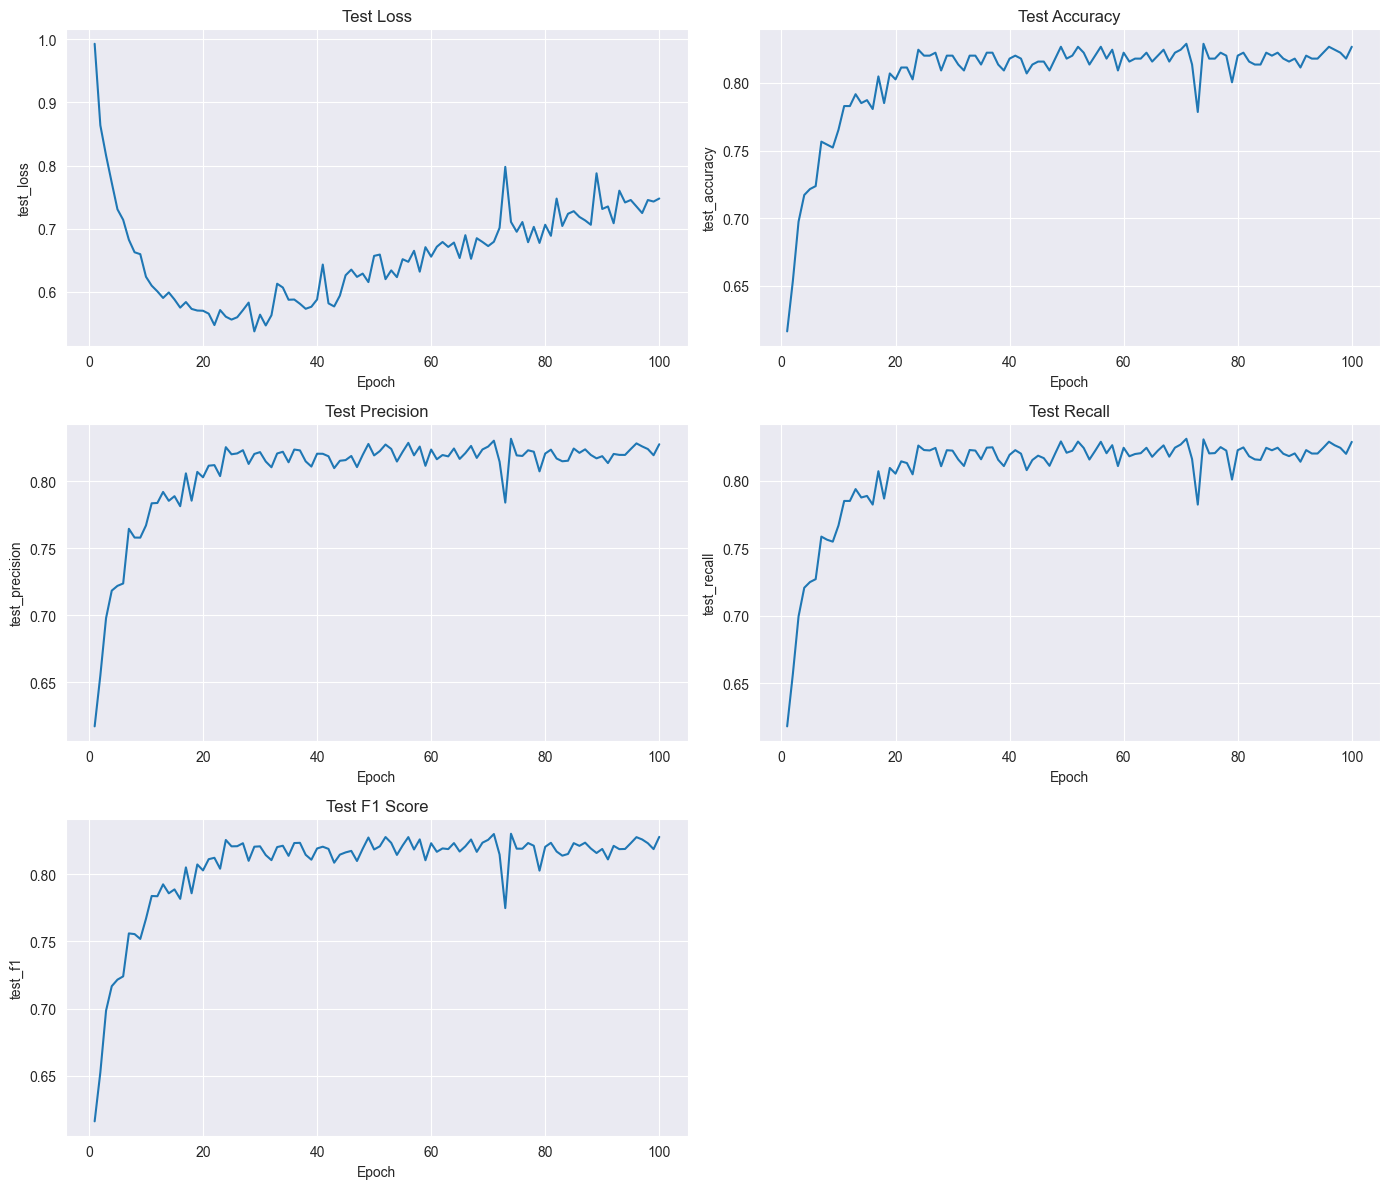

In [15]:
test_metrics_df = plot_testing_history(test_scores)

In [16]:
test_metrics_df

,epoch,test_loss,test_accuracy,test_precision,test_recall,test_f1
0,1,0.992929,0.616228,0.617003,0.618032,0.616078
1,2,0.863793,0.653509,0.655008,0.656757,0.652586
2,3,0.816092,0.697368,0.697773,0.699475,0.698458
3,4,0.772962,0.717105,0.718268,0.720693,0.716679
4,5,0.730812,0.721491,0.721814,0.724912,0.721542
5,6,0.714176,0.723684,0.723594,0.727063,0.723985
6,7,0.682626,0.756579,0.764391,0.758586,0.755963
7,8,0.662804,0.754386,0.757857,0.756279,0.755458
8,9,0.659776,0.752193,0.757790,0.754850,0.751858
9,10,0.624018,0.765351,0.766902,0.766834,0.766848


### Test Performance Trend (100 epochs)
The test metrics show a clear learning curve followed by saturation: performance improves rapidly in the early epochs as loss drops and accuracy rises from about 0.62 to ~0.76, then continues to improve more gradually until reaching a stable plateau around 0.81–0.83 accuracy with closely aligned precision, recall, and F1 scores. After roughly epochs 25–30, gains become marginal and the model mainly oscillates within a narrow performance band, indicating it has reached its generalization limit on the dataset. In later epochs (around 70+), small fluctuations appear with occasional dips, suggesting mild overfitting and optimization noise, but no sustained improvement beyond the peak region, which occurs around epochs 71–74 with the best F1/accuracy balance near ~0.83.

<b>Epoch 74</b>

* Loss = 0.710831
* Accuracy = 0.828947
* Precision = 0.831552
* Recall = 0.830613
* F1-Score = 0.830150